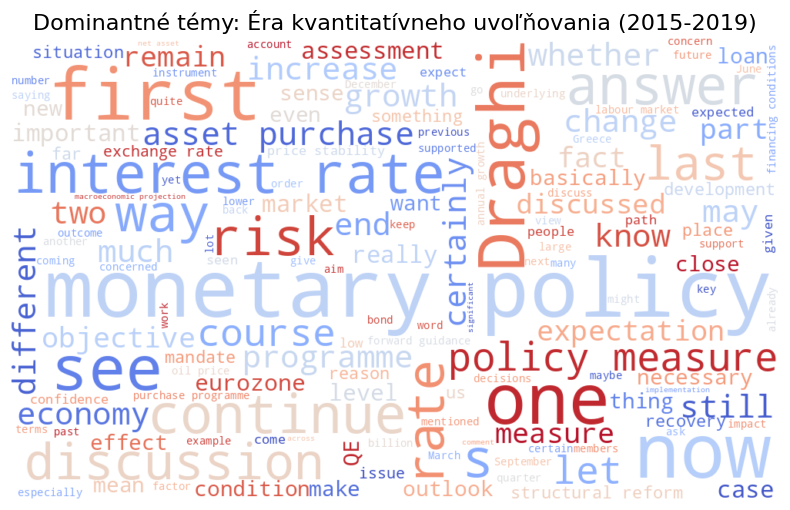

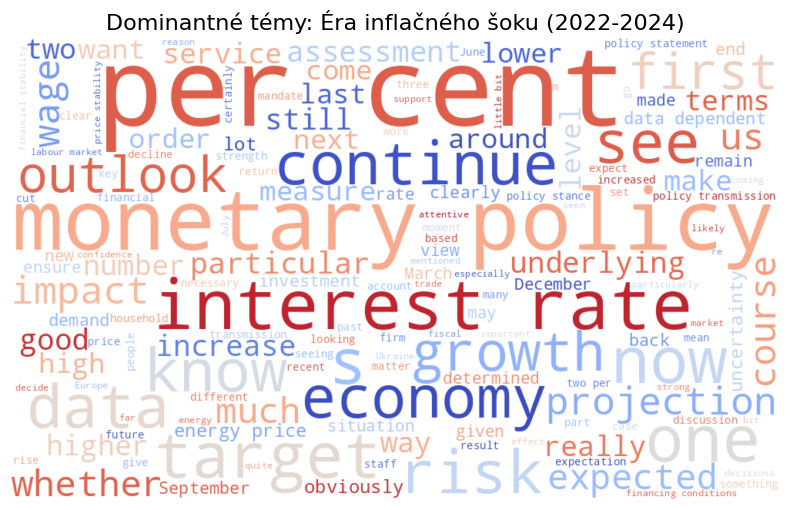

In [16]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 
from .. import DATA_DIR

# 1. Načítanie dát
df_scraped = pd.read_csv(f'{DATA_DIR}/scraped_v2.psv',sep="|")
df_scraped['date'] = pd.to_datetime(df_scraped['date'])

# 2. Definícia stop-words (balast, ktorý nechceme)
custom_stopwords = [
    # Procedurálne slová (v n-gramoch svietia najviac)
    'question', 'questions', 'second', 'mr', 'president', 'vice', 'lady', 'gentlemen', 
    'governing', 'council', 'meeting', 'press', 'conference', 'today', 'said', 'say', 
    'think', 'thank', 'afternoon', 'floor', 'disposal', 'decided', 'decision',
    "inflation",
    
    # Inštitucionálny balast (všetci vedia, že je to ECB v Eurozóne)
    'ecb', 'euro', 'area', 'european', 'central', 'bank', 'banks', 'countries', 
    'member', 'states', 'united', 'states', 'national',
    
    # Časové a pomocné výrazy
    'term', 'medium', 'short', 'long', 'longer', 'time', 'year', 'years', 'month', 
    'months', 'current', 'basis', 'point', 'points', 'actually', 'going', 'will', 
    'well', 'just', 'look', 'take', 'need', 'believe'
]

def generate_ecb_wordcloud(text_data, title):
    # Pridáme základné anglické stop-words z wordcloudu
    from wordcloud import STOPWORDS
    final_stopwords = STOPWORDS.union(set(custom_stopwords))
    
    wc = WordCloud(
        width=1000, height=600, 
        background_color='white',
        stopwords=final_stopwords,
        colormap='coolwarm', # Modrá (Dovish) -> Červená (Hawkish) feeling
        max_words=150
    ).generate(text_data)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# --- ANALÝZA 1: Éra nízkej inflácie (napr. 2015-2019) ---
era_low = df_scraped[(df_scraped['date'] > '2015-01-01') & (df_scraped['date'] < '2020-01-01')]
text_low = " ".join(era_low['intro'].fillna('') + " " + era_low['qa'].fillna(''))
generate_ecb_wordcloud(text_low, "Dominantné témy: Éra kvantitatívneho uvoľňovania (2015-2019)")

# --- ANALÝZA 2: Éra inflačného šoku (2022-2024) ---
era_high = df_scraped[df_scraped['date'] >= '2022-01-01']
text_high = " ".join(era_high['intro'].fillna('') + " " + era_high['qa'].fillna(''))
generate_ecb_wordcloud(text_high, "Dominantné témy: Éra inflačného šoku (2022-2024)")

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, n, top_k):
    # n=2 sú bigramy (dvojice), n=3 trigramy (trojice)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Načítaj texty (napr. z tvojho text_high pre inflačnú éru)
corpus = [text_high] # text_high musí byť list alebo series

print("Najčastejšie bigramy:")
print(get_top_ngrams(corpus, 2, 20))

print("\nNajčastejšie trigramy:")
print(get_top_ngrams(corpus, 3, 20))

Najčastejšie bigramy:
[('monetary policy', np.int64(701)), ('medium term', np.int64(360)), ('governing council', np.int64(319)), ('euro area', np.int64(287)), ('second question', np.int64(234)), ('underlying inflation', np.int64(181)), ('inflation outlook', np.int64(179)), ('data dependent', np.int64(145)), ('term target', np.int64(137)), ('basis points', np.int64(131)), ('policy transmission', np.int64(121)), ('energy prices', np.int64(120)), ('meeting meeting', np.int64(106)), ('policy statement', np.int64(104)), ('key ecb', np.int64(93)), ('ecb rates', np.int64(93)), ('vice president', np.int64(92)), ('policy stance', np.int64(90)), ('financing conditions', np.int64(88)), ('term inflation', np.int64(84))]

Najčastejšie trigramy:
[('medium term target', np.int64(137)), ('monetary policy transmission', np.int64(117)), ('monetary policy statement', np.int64(102)), ('key ecb rates', np.int64(93)), ('monetary policy stance', np.int64(84)), ('assessment inflation outlook', np.int64(70)), 

In [13]:
custom_stopwords.extend(['will', 'shall', 'going', 'think', 'look', 'want', 'need', 'say', 'said', 'weve', 'youre'])

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
# Spojíme všetko do jedného veľkého textu (odstránime NaN)
full_text = " ".join(df_scraped['intro'].fillna('') + " " + df_scraped['qa'].fillna(''))

def print_top_ngrams(text, n, top_k):
    # n=1: slová, n=2: dvojice, n=3: trojice
    # stop_words='english' vyhodí základné slová ako "the", "a", "is"...
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit([text])
    bag_of_words = vec.transform([text])
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    print(f"\n--- TOP {top_k} N-GRAMS (n={n}) ---")
    for i, (word, freq) in enumerate(words_freq[:top_k]):
        print(f"{i+1}. {word}: {freq}")

# 2. Vypíšeme si zoznamy
print_top_ngrams(full_text, n=1, top_k=30) # Jednotlivé slová
print_top_ngrams(full_text, n=2, top_k=30) # Dvojice
print_top_ngrams(full_text, n=3, top_k=30) # Trojice


--- TOP 30 N-GRAMS (n=1) ---
1. question: 9206
2. euro: 7572
3. inflation: 7513
4. growth: 6281
5. monetary: 6115
6. area: 5504
7. policy: 5183
8. rates: 5000
9. ecb: 4578
10. price: 4456
11. council: 4430
12. said: 4323
13. term: 4320
14. rate: 4220
15. second: 3991
16. governing: 3891
17. economic: 3879
18. time: 3765
19. stability: 3633
20. say: 3580
21. think: 3258
22. market: 3066
23. today: 2938
24. medium: 2911
25. financial: 2791
26. economy: 2708
27. risks: 2689
28. year: 2600
29. banks: 2563
30. countries: 2462

--- TOP 30 N-GRAMS (n=2) ---
1. euro area: 5315
2. governing council: 3879
3. monetary policy: 3618
4. price stability: 2621
5. medium term: 2330
6. second question: 1950
7. inflation expectations: 918
8. central bank: 912
9. question mr: 766
10. central banks: 761
11. vice president: 741
12. exchange rate: 726
13. structural reforms: 708
14. economic activity: 678
15. inflation rates: 649
16. short term: 602
17. policy stance: 576
18. financing conditions: 568
19. e